# EMAIL SPAM DETECTION WITH MACHINE LEARNING

## Loading Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.feature_extraction.text import CountVectorizer 
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

## Loading Dataset

In [2]:
df = pd.read_csv("spam.csv", encoding = 'latin-1')
df.head()
df.drop(columns=['Unnamed: 2',"Unnamed: 3","Unnamed: 4"], inplace= True)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Data Cleaning

In [3]:
df.columns = ['Label','Message']
print(df.head())

  Label                                            Message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [4]:
df.isnull().sum()

Label      0
Message    0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Label    5572 non-null   object
 1   Message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


## Label Encoding

In [6]:
df['Label']= df['Label'].str.strip().str.lower()
df['Label'] = df['Label'].map({'ham':0,'spam':1})
df.head()

,Label,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Label    5572 non-null   int64 
 1   Message  5572 non-null   object
dtypes: int64(1), object(1)
memory usage: 87.2+ KB


## Visualization

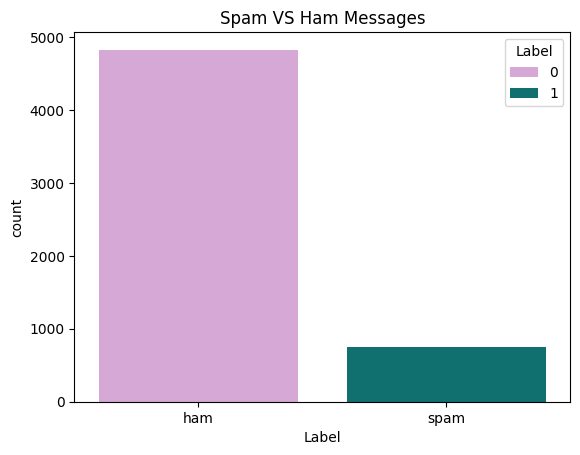

In [8]:
sns.countplot(x=df['Label'],hue=df["Label"], palette= ['plum','teal'])
plt.xticks([0,1],['ham','spam'])
plt.title("Spam VS Ham Messages")
plt.show()

## Training Model

In [9]:
X = df['Message']
y = df['Label']

cv = CountVectorizer()

X = cv.fit_transform(X).toarray()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
model = MultinomialNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


## Testing Model

In [12]:
y_pred = model.predict(X_test)

In [13]:
print("Accuracy:", accuracy_score(y_test,y_pred))

Accuracy: 0.97847533632287


In [14]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[952,  13],
       [ 11, 139]])

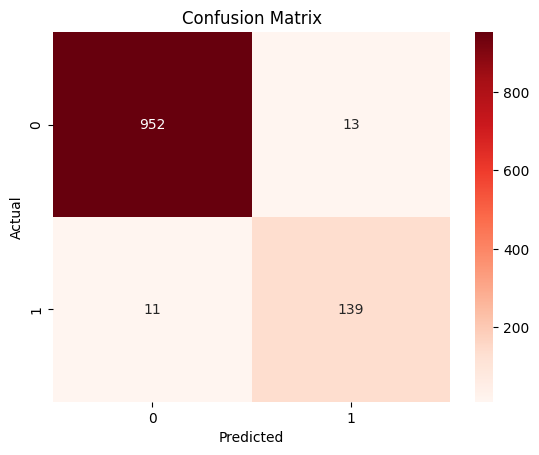

In [15]:
sns.heatmap(cm,annot = True, fmt= 'd', cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Model Evaluation

In [16]:
msg = ["Congratulations! You won a free gift"]
msg = cv.transform(msg) 
prediction = model.predict(msg)
if prediction[0] == 1:
    print("Spam Message")
else:
    print("Ham Message")

Spam Message


In [17]:
msg2 = ["Hey, are we still meeting for lunch today?"]
msg2 = cv.transform(msg2)
prediction2 = model.predict(msg2)
if prediction2[0] == 1:
    print("Spam Message")
else:
    print("Ham Message")

Ham Message
